In [194]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot(title, label, x, result, expected):
    plt.plot(x, expected, label=f'Ground truth')
    plt.plot(x, result, label=f'Sequre {label}')
    plt.title(title)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True)
    plt.show()

def mae(result, expected):
    return np.mean(np.abs(np.array(result) - np.array(expected)))

def mxae(result, expected):
    return np.max(np.abs(np.array(result) - np.array(expected)))

In [195]:
""" Core methods """

# Until Codon Jupyter is fixed: Read the data from files
show_plots = False

dump_folder = "dump"
dump_files = [
    "decor_trig",
    "decor",
    "fourier",
    "cheby",
    "taylor"
    ]
nbit_fs = [32, 64]
intervals_count = 4
cps = [0, 1]
exclude = ["sinh", "cosh", "tanh"]

df_data = {
    'Method': [],
    'Interval': [],
    'MAE': [],
    'MXAE': [],
    'Runtime': [],
    'Partitions count': [],
    'Truncations count': []
    }

for cp in cps:
    df_data[f'Bytes sent CP{cp}'] = []
    df_data[f'Requests sent CP{cp}'] = []

for dump_file in dump_files:
    for nbit_f in nbit_fs:
        for i in range(intervals_count):
            for cp in cps:
                try:
                    with open(f"{dump_folder}/{dump_file}_{i}_{nbit_f}_CP{cp}.p", "rb") as f:
                        data = pickle.load(f)
                        x = data['x']
                        interval = f"({round(min(x), 2)}, {round(max(x), 2)})"
                        for k, v in data.items():
                            if not k.endswith('_result'):
                                continue

                            skip = False
                            for exclude_item in exclude:
                                if exclude_item in k:
                                    skip = True
                                    break
                            
                            if skip:
                                continue

                            k = k.replace('_result', '')
                            expected = data[f"{k}_expected"]

                            runtime = round(data[f"{k}_time"][0], 5)
                            bytes_sent = int(data[f"{k}_bytes_sent"][0])
                            send_requests = int(data[f"{k}_send_requests"][0])
                            partitions_count = int(data[f"{k}_partitions_count"][0])
                            truncations_count = int(data[f"{k}_truncations_count"][0])
                            
                            if cp == 1:
                                df_data['Method'].append(f"{k}_{nbit_f}")
                                df_data['Interval'].append(interval)
                                df_data['MAE'].append(mae(v, expected))
                                df_data['MXAE'].append(mxae(v, expected))

                                df_data['Runtime'].append(runtime)
                                df_data['Partitions count'].append(partitions_count)
                                df_data['Truncations count'].append(truncations_count)

                            df_data[f'Bytes sent CP{cp}'].append(bytes_sent)
                            df_data[f'Requests sent CP{cp}'].append(send_requests)
                            
                            if show_plots and cp == 1:
                                plot(f"{k} {nbit_f} frac bits on {interval}", k, x, v, expected)
                except FileNotFoundError:
                    print(f"Could not find {dump_folder}/{dump_file}_{i}_{nbit_f}.p")

df = pd.DataFrame(df_data)

Could not find dump/decor_trig_0_64.p
Could not find dump/decor_trig_0_64.p
Could not find dump/decor_trig_1_64.p
Could not find dump/decor_trig_1_64.p
Could not find dump/decor_trig_2_64.p
Could not find dump/decor_trig_2_64.p
Could not find dump/decor_trig_3_64.p
Could not find dump/decor_trig_3_64.p
Could not find dump/decor_0_64.p
Could not find dump/decor_0_64.p
Could not find dump/decor_1_64.p
Could not find dump/decor_1_64.p
Could not find dump/decor_2_64.p
Could not find dump/decor_2_64.p
Could not find dump/decor_3_64.p
Could not find dump/decor_3_64.p
Could not find dump/fourier_0_64.p
Could not find dump/fourier_0_64.p
Could not find dump/fourier_1_64.p
Could not find dump/fourier_1_64.p
Could not find dump/fourier_2_64.p
Could not find dump/fourier_2_64.p
Could not find dump/fourier_3_64.p
Could not find dump/fourier_3_64.p
Could not find dump/cheby_0_64.p
Could not find dump/cheby_0_64.p
Could not find dump/cheby_1_64.p
Could not find dump/cheby_1_64.p
Could not find dump/

In [196]:
def by_interval(df):
    for interval, group in df.groupby('Interval'):
        display(group)

In [197]:
display_methods = [
    "sin_", "cos_", "tan_", "cot", "exp",
    "sigmoid", "sinh", "cosh", "tanh",
    "sqrt", "log", "mul_inv", "polynomial"]

for method in display_methods:
    display(by_interval(df[df['Method'].str.contains(method)].sort_values(by='MAE')))

,Method,Interval,MAE,MXAE,Runtime,Partitions count,Truncations count,Bytes sent CP0,Requests sent CP0,Bytes sent CP1,Requests sent CP1
83,chebyshev_10_sin_naive_32,"(-0.79, 0.79)",1.514702e-10,3.734097e-10,0.00142,10,12,82160,68,53160,44
79,chebyshev_10_sin_clenshaw_32,"(-0.79, 0.79)",3.649628e-10,1.499627e-09,0.00180,10,12,82144,68,53152,44
6,decor_sin_32,"(-0.79, 0.79)",1.082899e-09,1.629000e-09,0.00006,2,1,9664,8,4832,4
89,chebyshev_10_sin_decor_32,"(-0.79, 0.79)",2.633253e-09,3.761606e-08,0.00251,24,4,66968,50,36624,58
140,taylor_6_sin_decor_32,"(-0.79, 0.79)",4.866476e-06,3.626524e-05,0.00193,24,3,52504,46,34208,56
142,taylor_6_sin_naive_32,"(-0.79, 0.79)",4.866551e-06,3.626478e-05,0.00142,6,7,48336,40,31416,26
33,fourier_10_sin_32,"(-0.79, 0.79)",5.095119e-02,7.071068e-01,0.00210,2,1,96384,8,26512,4


,Method,Interval,MAE,MXAE,Runtime,Partitions count,Truncations count,Bytes sent CP0,Requests sent CP0,Bytes sent CP1,Requests sent CP1
1,decor_sin_32,"(-10.0, 10.0)",6.586583e-10,1.447056e-09,0.00006,2,1,9664,8,4832,4
22,fourier_10_sin_32,"(-10.0, 10.0)",4.125075e-02,5.440211e-01,0.00202,2,1,96384,8,26512,4
53,chebyshev_10_sin_clenshaw_32,"(-10.0, 10.0)",1.813959e-01,3.724272e-01,0.00153,10,12,82144,68,53152,44
46,chebyshev_10_sin_naive_32,"(-10.0, 10.0)",1.813959e-01,3.724273e-01,0.00169,10,12,82160,68,53160,44
120,taylor_6_sin_naive_32,"(-10.0, 10.0)",1.079141e+02,6.772107e+02,0.00021,6,7,48336,40,31416,26
118,taylor_6_sin_decor_32,"(-10.0, 10.0)",1.079141e+02,6.772107e+02,0.00181,24,3,52504,46,34208,56


,Method,Interval,MAE,MXAE,Runtime,Partitions count,Truncations count,Bytes sent CP0,Requests sent CP0,Bytes sent CP1,Requests sent CP1
97,chebyshev_10_sin_naive_32,"(0.79, 2.36)",1.487008e-10,5.571348e-10,0.00038,10,12,82160,68,53160,44
9,decor_sin_32,"(0.79, 2.36)",3.478286e-10,9.877633e-10,0.00006,2,1,9664,8,4832,4
95,chebyshev_10_sin_clenshaw_32,"(0.79, 2.36)",3.805508e-10,1.278791e-09,0.00228,10,12,82144,68,53152,44
113,chebyshev_10_sin_decor_32,"(0.79, 2.36)",3.011207e-09,3.572142e-08,0.00301,24,4,66968,50,36624,58
149,taylor_6_sin_naive_32,"(0.79, 2.36)",4.294475e-07,3.566494e-06,0.00023,6,7,48336,40,31416,26
155,taylor_6_sin_decor_32,"(0.79, 2.36)",4.294838e-07,3.566261e-06,0.00239,24,3,52504,46,34208,56
39,fourier_10_sin_32,"(0.79, 2.36)",9.267858e-04,1.070810e-02,0.00083,2,1,96384,8,26512,4


,Method,Interval,MAE,MXAE,Runtime,Partitions count,Truncations count,Bytes sent CP0,Requests sent CP0,Bytes sent CP1,Requests sent CP1
26,fourier_10_sin_32,"(3.14, 9.42)",5.238614e-10,1.456620e-09,0.00010,2,1,9696,8,4840,4
3,decor_sin_32,"(3.14, 9.42)",5.461751e-10,1.689451e-09,0.00006,2,1,9664,8,4832,4
60,chebyshev_10_sin_naive_32,"(3.14, 9.42)",3.822439e-06,6.004465e-06,0.00039,10,12,82160,68,53160,44
59,chebyshev_10_sin_clenshaw_32,"(3.14, 9.42)",3.822465e-06,6.003533e-06,0.00040,10,12,82144,68,53152,44
74,chebyshev_10_sin_decor_32,"(3.14, 9.42)",3.822905e-06,6.002369e-06,0.00260,24,4,66968,50,36624,58
127,taylor_6_sin_naive_32,"(3.14, 9.42)",7.196224e-02,5.240439e-01,0.00052,6,7,48336,40,31416,26
133,taylor_6_sin_decor_32,"(3.14, 9.42)",7.196225e-02,5.240439e-01,0.00200,24,3,52504,46,34208,56


None

...

,Method,Interval,MAE,MXAE,Runtime,Partitions count,Truncations count,Bytes sent CP0,Requests sent CP0,Bytes sent CP1,Requests sent CP1
18,decor_polynomial_32,"(-0.79, 0.79)",1.989108e-09,1.006778e-08,0.00106,24,3,45280,46,34208,56


,Method,Interval,MAE,MXAE,Runtime,Partitions count,Truncations count,Bytes sent CP0,Requests sent CP0,Bytes sent CP1,Requests sent CP1
12,decor_polynomial_32,"(-10.0, 10.0)",0.000016,0.000094,0.00136,24,3,45280,46,34208,56


,Method,Interval,MAE,MXAE,Runtime,Partitions count,Truncations count,Bytes sent CP0,Requests sent CP0,Bytes sent CP1,Requests sent CP1
21,decor_polynomial_32,"(0.79, 2.36)",1.154377e-08,4.141216e-08,0.00153,24,3,45280,46,34208,56


,Method,Interval,MAE,MXAE,Runtime,Partitions count,Truncations count,Bytes sent CP0,Requests sent CP0,Bytes sent CP1,Requests sent CP1
15,decor_polynomial_32,"(3.14, 9.42)",0.000002,0.000007,0.00062,24,3,45280,46,34208,56


None

In [198]:
""" E2E apps """

# Until Codon Jupyter is fixed: Read the data from files
dump_files = [
    "log_reg",
    "dti"
    ]

df_data = {
    'Method': [],
    'Accuracy': [],
    'Runtime': [],
    'Bytes sent': [],
    'Requests sent': [],
    'Partitions count': [],
    'Truncations count': []
    }

for dump_file in dump_files:
    for nbit_f in nbit_fs:
        for cp in cps:
            try:
                with open(f"{dump_folder}/{dump_file}_{nbit_f}_CP{cp}.p", "rb") as f:
                    data = pickle.load(f)
                    for k, v in data.items():
                        if not k.endswith('_accuracy'):
                            continue
                        
                        k = k.replace('_accuracy', '')
                        accuracy = data[f"{k}_accuracy"][0]
                        runtime = round(data[f"{k}_time"][0], 5)
                        bytes_sent = int(data[f"{k}_bytes_sent"][0])
                        send_requests = int(data[f"{k}_send_requests"][0])
                        partitions_count = int(data[f"{k}_partitions_count"][0])
                        truncations_count = int(data[f"{k}_truncations_count"][0])
                        
                        df_data['Method'].append(f"{k}_{nbit_f}")
                        
                        df_data['Accuracy'].append(accuracy)
                        df_data['Runtime'].append(runtime)
                        df_data['Bytes sent'].append(bytes_sent)
                        df_data['Requests sent'].append(send_requests)
                        df_data['Partitions count'].append(partitions_count)
                        df_data['Truncations count'].append(truncations_count)
            except FileNotFoundError:
                print(f"Could not find {dump_folder}/{dump_file}_{nbit_f}_CP{cp}.p")

e2e_df = pd.DataFrame(df_data)

Could not find dump/log_reg_64_CP0.p
Could not find dump/log_reg_64_CP1.p
Could not find dump/dti_32_CP0.p
Could not find dump/dti_32_CP1.p
Could not find dump/dti_64_CP0.p
Could not find dump/dti_64_CP1.p


In [199]:
e2e_df[e2e_df['Method'].str.contains('binary')].sort_values(by='Accuracy', ascending=False)

,Method,Accuracy,Runtime,Bytes sent,Requests sent,Partitions count,Truncations count
1,log_reg_binary_chebyshev_32,1.0000,0.02688,359680,1680,241,300
2,log_reg_binary_fourier_32,1.0000,0.17098,402560,480,81,80
4,log_reg_binary_decor_32,1.0000,0.06739,1038080,7240,3761,560
7,log_reg_binary_chebyshev_32,0.9375,0.01815,237392,1082,241,300
10,log_reg_binary_decor_32,0.9375,0.06759,1009232,8842,3761,560
8,log_reg_binary_fourier_32,0.6250,0.17681,148112,282,81,80


In [200]:
e2e_df[e2e_df['Method'].str.contains('multinomial')].sort_values(by='Accuracy', ascending=False)

,Method,Accuracy,Runtime,Bytes sent,Requests sent,Partitions count,Truncations count
0,log_reg_multinomial_decor_32,1.0000,0.18174,4855840,4200,2801,120
3,log_reg_multinomial_fourier_32,1.0000,0.35753,5415200,3440,2361,80
5,log_reg_multinomial_chebyshev_32,1.0000,0.17570,5280160,4640,2521,300
9,log_reg_multinomial_fourier_32,0.9375,0.35783,2458512,5122,2361,80
6,log_reg_multinomial_decor_32,0.8750,0.18423,2537552,6162,2801,120
11,log_reg_multinomial_chebyshev_32,0.8750,0.17202,2716752,5922,2521,300


In [201]:
e2e_df[e2e_df['Method'].str.contains('dti')].sort_values(by='Accuracy', ascending=False)

,Method,Accuracy,Runtime,Bytes sent,Requests sent,Partitions count,Truncations count


In [202]:
import math


def by_name(name, df):
    return df[df['Method'].str.startswith(name)]

def plot_accuracy_vs_perf(
        df, methods=["sin", "cos", "exp", "sigmoid"],
        metric="Runtime", intervals=["(-10.0, 10.0)"],
        approaches=["decor", "chebyshev", "fourier", "taylor"],
        markers=["o", "s", "^", "v"], remove_outliers=False):
    
    _, axs = plt.subplots(2, 2, figsize=(12, 10))
    for idx, method in enumerate(methods):
        ax = axs[idx // 2, idx % 2]

        filtered_df = df[df['Method'].str.contains(f"{method}_")]
        filtered_df = filtered_df[
            ~filtered_df['Method'].str.contains('_decor') &
            (~filtered_df['Method'].str.contains('_naive') |
             filtered_df['Method'].str.contains('taylor_'))
        ]
        filtered_df['Method'] = filtered_df['Method'].str.replace(f"{method}_", "", regex=False)
        
        if remove_outliers:
            filtered_df = filtered_df[filtered_df['MAE'] < 0.5]
        
        # Convert MAE to accuracy
        filtered_df['MAE'] = filtered_df['MAE'].apply(lambda x: -math.log(x))
        
        for interval, group in filtered_df.groupby('Interval'):
            if interval not in intervals:
                print(f"Skipping interval {interval}")
                continue
            for approach, marker in zip(approaches, markers):
                filtered_group = group[group['Method'].str.startswith(approach)]
                if filtered_group.empty:
                    continue
                ax.scatter(
                    filtered_group[metric], filtered_group["MAE"],
                    label=approach.capitalize(), marker=marker, s=100,
                    edgecolors=[
                        ('black' if m.endswith('64') else 'none') for m in filtered_group['Method']],
                )
            ax.set_title(f"{method} at {interval}")
            ax.set_xlabel(metric)
            ax.set_ylabel("Accuracy: -log(MAE)")
            ax.grid(True)
        if idx == 1:
            ax.legend(title="Bordered: 64 bits\nNon-bordered: 32 bits", loc='upper right')
    
    plt.tight_layout()
    plt.show()

Skipping interval (-0.79, 0.79)
Skipping interval (0.79, 2.36)
Skipping interval (3.14, 9.42)
Skipping interval (-0.79, 0.79)
Skipping interval (0.79, 2.36)
Skipping interval (3.14, 9.42)
Skipping interval (-0.79, 0.79)
Skipping interval (0.79, 2.36)
Skipping interval (3.14, 9.42)
Skipping interval (-0.79, 0.79)
Skipping interval (0.79, 2.36)
Skipping interval (3.14, 9.42)


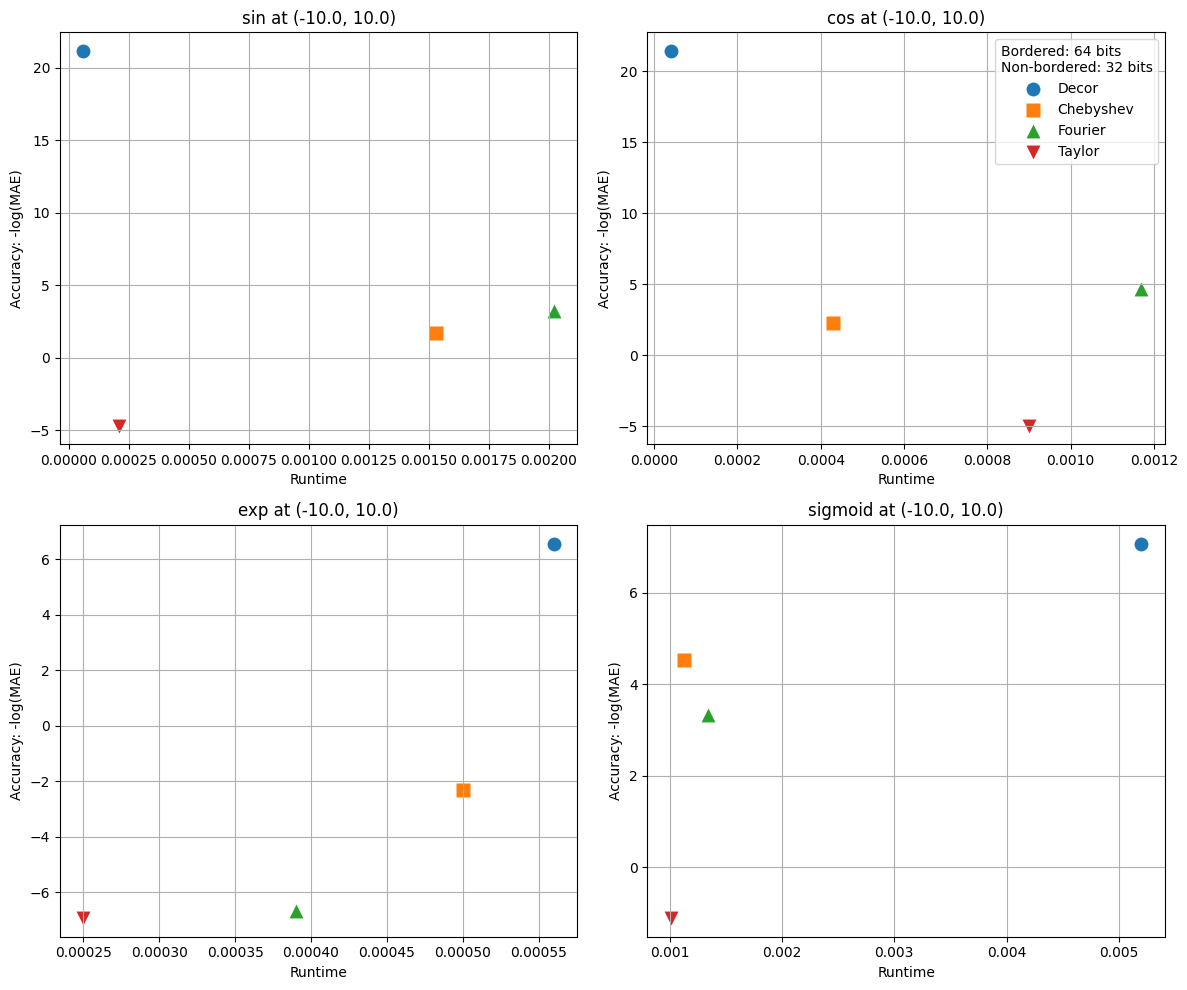

In [203]:
plot_accuracy_vs_perf(df)